# Time-varying age at sexual debut

*New in v1.5.4*

Age at first sex (AFS) has changed markedly in many settings — in Sub-Saharan
Africa, for example, DHS surveys consistently show a downward drift in median
AFS over recent decades. This example shows how to model that drift in STIsim
using **callable parameters**: instead of a static mean, we pass a function
that returns the mean at each simulation time.

This works because the underlying Starsim distributions accept any parameter
as either a scalar, an array, or a callable of `sim` / `uids`. STIsim plumbs
the `debut_f` and `debut_m` distributions straight through, so anything you
can express as a distribution parameter works here — linear trends, sigmoids,
DHS-fitted splines, you name it.


## Setup

We'll use a simple HIV sim spanning 1985-2025 with 10,000 agents, and compare
two scenarios: a static debut distribution (default) vs a dynamic one whose
mean declines linearly from 20 to 17 over the simulation period.


In [1]:
import numpy as np
import pandas as pd
import sciris as sc
import starsim as ss
import stisim as sti
import hivsim
import matplotlib.pyplot as plt

sc.options(dpi=110)
np.random.seed(0)


## Baseline: static debut

In the default `StructuredSexual` network, `debut_f` and `debut_m` are
lognormal distributions with a fixed mean (20 for women, 21 for men).
Everyone who enters the simulation — at init or via births — draws their
age of first sex from the same distribution.


In [2]:
def make_sim(debut_f, debut_m, label):
    net = sti.StructuredSexual(debut_f=debut_f, debut_m=debut_m)
    sim = hivsim.demo(
        'simple', run=False, plot=False,
        n_agents=10_000, start=1985, stop=2025, rand_seed=1, verbose=0,
    )
    sim.pars.networks = [net]
    sim.label = label
    return sim


sim_static = make_sim(
    debut_f=ss.lognorm_ex(20, 3),
    debut_m=ss.lognorm_ex(21, 3),
    label='Static',
)


## Time-varying debut

Now we define a callable that returns the mean age at debut as a function of
the current simulation year. The function can take any of `sim`, `self` /
`module`, `uids`, `size`, `pars`, `states` as arguments — Starsim introspects
the signature and passes what's asked for.

Here we keep it simple: linear decline from 20 in 1985 down to 17 by 2025,
floored at 17 for any time outside the window.


In [3]:
def mean_afs_f(sim):
    # Linear decline: 20 in 1985, 17 in 2025, clipped outside
    return float(np.clip(20 - 0.075 * (sim.now.years - 1985), 17, 20))


def mean_afs_m(sim):
    return float(np.clip(21 - 0.075 * (sim.now.years - 1985), 18, 21))


sim_dynamic = make_sim(
    debut_f=ss.lognorm_ex(mean=mean_afs_f, std=3),
    debut_m=ss.lognorm_ex(mean=mean_afs_m, std=3),
    label='Dynamic',
)


## Run and compare

We run both sims in parallel, then compute mean debut age by birth-year
cohort. In the static sim, cohorts should look identical. In the dynamic
sim, later cohorts should show progressively lower mean AFS.


In [4]:
msim = ss.parallel(sim_static, sim_dynamic)

def afs_by_cohort(sim, cohort_bin=5):
    ppl = sim.people
    net = sim.networks.structuredsexual
    alive = ppl.alive.uids
    debut = net.debut[alive]
    age   = ppl.age[alive]
    born  = sim.now.years - age
    # Only include agents who have debuted
    has_debut = debut > 0
    born   = born[has_debut]
    debut  = debut[has_debut]
    female = ppl.female[alive][has_debut]

    bin_edges   = np.arange(1960, 2011, cohort_bin)
    bin_centers = bin_edges[:-1] + cohort_bin / 2

    out = {}
    for sex_name, mask in [('Female', female), ('Male', ~female)]:
        means = []
        for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
            in_bin = mask & (born >= lo) & (born < hi)
            means.append(np.nan if not in_bin.any() else debut[in_bin].mean())
        out[sex_name] = np.array(means)
    return bin_centers, out


cohorts_static,  means_static  = afs_by_cohort(msim.sims[0])
cohorts_dynamic, means_dynamic = afs_by_cohort(msim.sims[1])


## Visualize

Plot mean AFS by birth-year cohort for both scenarios and both sexes.


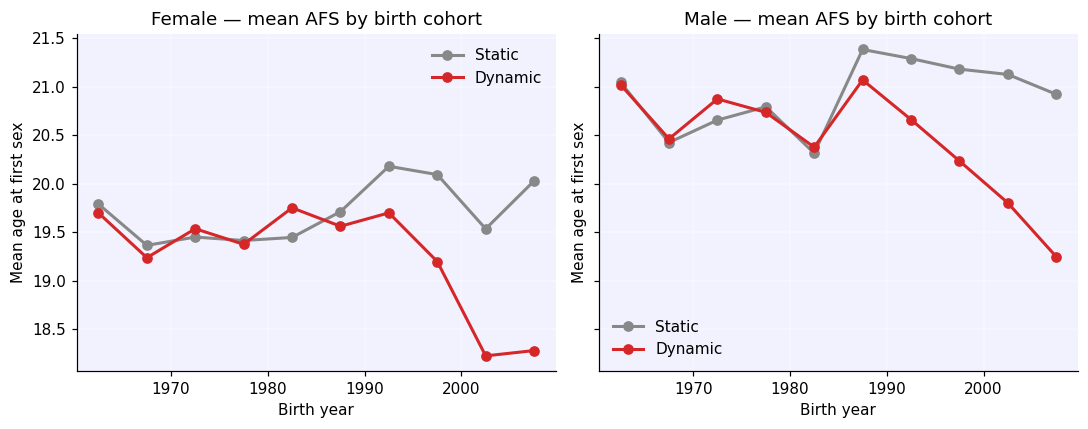

In [5]:
with sc.options.with_style('fancy'):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    colors = {'Static': '#888', 'Dynamic': '#d62728'}

    for ax, sex in zip(axes, ['Female', 'Male']):
        ax.plot(cohorts_static,  means_static[sex],  'o-', color=colors['Static'],  label='Static')
        ax.plot(cohorts_dynamic, means_dynamic[sex], 'o-', color=colors['Dynamic'], label='Dynamic')
        ax.set_title(f'{sex} — mean AFS by birth cohort')
        ax.set_xlabel('Birth year')
        ax.set_ylabel('Mean age at first sex')
        ax.grid(alpha=0.3)
        ax.legend()

    fig.tight_layout()
    plt.show()


## Key takeaways

- **Distribution parameters are callables** — anything starsim accepts
  (scalars, arrays, or functions of `sim` / `uids`) works for `debut_f`
  and `debut_m`.
- **Use what fits your data** — a linear trend like the above, a sigmoid,
  or a spline fit to DHS indicators all plug in identically.
- **No subclassing required** — time-varying behavior is just a callable
  passed at network construction. Same pattern extends to other
  distribution parameters in the network (age differences, concurrency,
  relationship durations, etc.).
- **Be bounded** — because callables are unconstrained, use `np.clip` or
  similar to keep the trend physically plausible over your simulation
  window.
